<a href="https://colab.research.google.com/github/vodnalasuhas/DAA-CSE-C/blob/main/EXP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

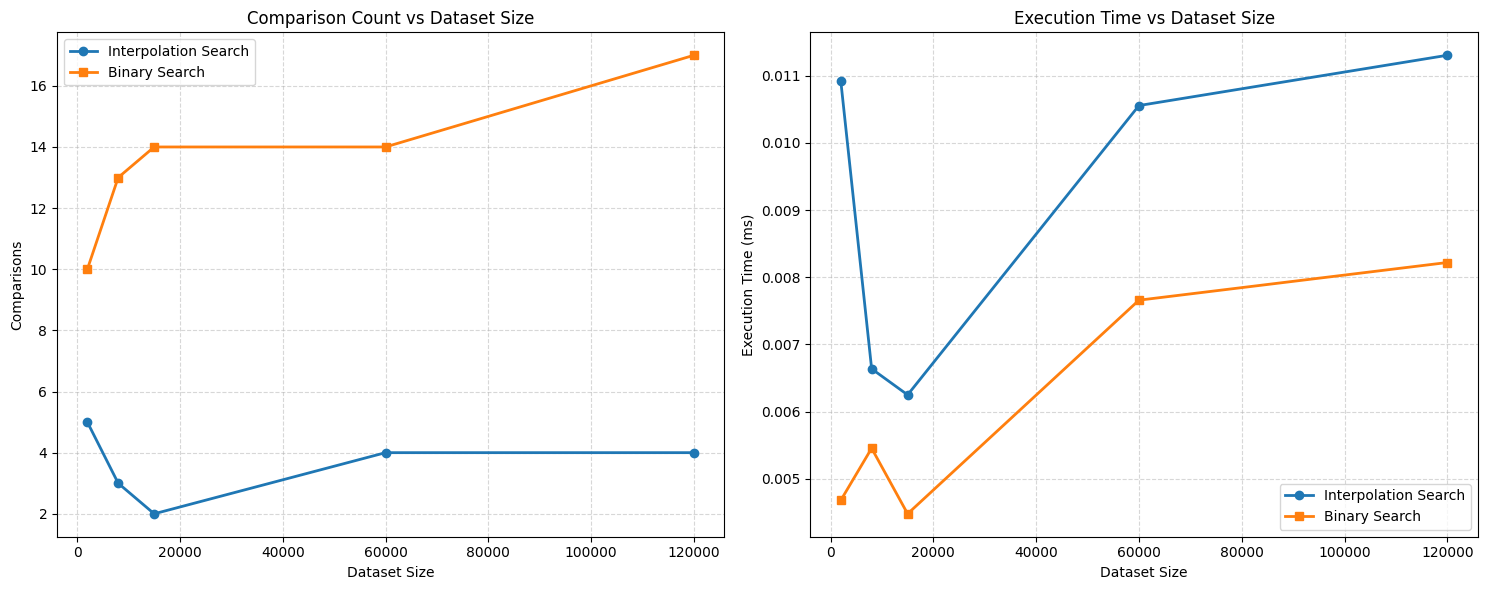

In [2]:
import random
import time
import matplotlib.pyplot as plt

# -------------------- Interpolation Search --------------------
def interp_search(data, key):
    left = 0
    right = len(data) - 1
    count = 0

    while left <= right and data[left] <= key <= data[right]:

        if data[left] == data[right]:
            count += 1
            if data[left] == key:
                return left, count
            break

        count += 1

        index = left + ((key - data[left]) * (right - left)) // (data[right] - data[left])

        if data[index] == key:
            return index, count
        elif data[index] < key:
            left = index + 1
        else:
            right = index - 1

    return -1, count


# -------------------- Binary Search --------------------
def bin_search(data, key):
    start = 0
    end = len(data) - 1
    count = 0

    while start <= end:
        count += 1
        middle = (start + end) // 2

        if data[middle] == key:
            return middle, count

        if key > data[middle]:
            start = middle + 1
        else:
            end = middle - 1

    return -1, count


# -------------------- Performance Test --------------------
input_sizes = [2000, 8000, 15000, 60000, 120000]

interp_time = []
binary_time = []

interp_compare = []
binary_compare = []

for n in input_sizes:

    values = sorted(random.sample(range(n * 15), n))
    search_value = random.choice(values)

    # Interpolation Search
    t1 = time.perf_counter()
    _, c1 = interp_search(values, search_value)
    t2 = time.perf_counter()

    interp_time.append((t2 - t1) * 1000)
    interp_compare.append(c1)

    # Binary Search
    t3 = time.perf_counter()
    _, c2 = bin_search(values, search_value)
    t4 = time.perf_counter()

    binary_time.append((t4 - t3) * 1000)
    binary_compare.append(c2)


# -------------------- Graphs --------------------
plt.figure(figsize=(15,6))

# Comparison Graph
plt.subplot(1,2,1)
plt.plot(input_sizes, interp_compare,
         marker='o',
         linestyle='-',
         linewidth=2,
         label='Interpolation Search')

plt.plot(input_sizes, binary_compare,
         marker='s',
         linestyle='-',
         linewidth=2,
         label='Binary Search')

plt.title("Comparison Count vs Dataset Size")
plt.xlabel("Dataset Size")
plt.ylabel("Comparisons")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()


# Execution Time Graph
plt.subplot(1,2,2)
plt.plot(input_sizes, interp_time,
         marker='o',
         linestyle='-',
         linewidth=2,
         label='Interpolation Search')

plt.plot(input_sizes, binary_time,
         marker='s',
         linestyle='-',
         linewidth=2,
         label='Binary Search')

plt.title("Execution Time vs Dataset Size")
plt.xlabel("Dataset Size")
plt.ylabel("Execution Time (ms)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()